## Step 1: PEAS Description
Before diving into the code, let's define the PEAS (Performance, Environment, Actuators, Sensors) for our Rescue Robot agent:

*   **Performance Measure**: Maximize survivors rescued, minimize cost/distance traveled, minimize toxic zones crossed, minimize execution time/nodes explored.
*   **Environment**: An 8x8 discrete, static, deterministic, and fully observable grid. The grid consists of Safe passages (`.`), Toxic Gas zones (`T`), Blocked Passages (`#`), the Start point (`S`), and Survivors/Goals (`P`).
*   **Actuators**: Orthogonal movement mechanisms (Up, Down, Left, Right). Rescue tool (to rescue the survivor and mark the node as safe).
*   **Sensors**: Location tracking (row, col coordinates), environment scanner (to detect blocked or toxic status of adjacent nodes for heuristic 2), survivor locator.

Initial Text Grid:
S . . # . T . .
# . T # . . . .
. . . . T . # .
. # # . . . . .
T . . . # # . P
. . . T . . . .
. # . . P # T .
. . . T . P . .


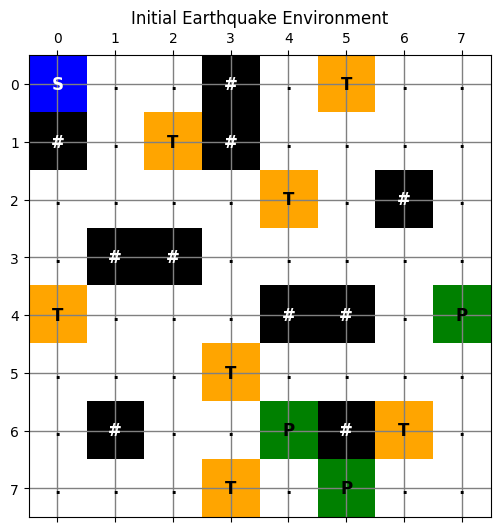

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Step 2: Environment Setup

def read_input_file(filepath):
    """
    Reads the environment grid from a text file.
    
    Args:
        filepath (str): The path to the text file containing the grid layout.
        
    Returns:
        list: A 2D list (matrix) representing the grid environment.
    """
    grid = []
    if os.path.exists(filepath):
        with open(filepath, 'r') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                # Handling comma-separated or space-separated or just continuous characters
                if ',' in line:
                    grid.append(line.split(','))
                elif ' ' in line:
                    grid.append(line.split(' '))
                else:
                    grid.append(list(line))
        return grid
    else:
        print(f"File {filepath} not found. Returning a default grid.")
        return [
            ['S', '.', '.', '#', '.', 'T', '.', '.'],
            ['#', '.', 'T', '#', '.', '.', '.', '.'],
            ['.', '.', '.', '.', 'T', '.', '#', '.'],
            ['.', '#', '#', '.', '.', '.', '.', '.'],
            ['T', '.', '.', '.', '#', '#', '.', 'P'],
            ['.', '.', '.', 'T', '.', '.', '.', '.'],
            ['.', '#', '.', '.', 'P', '#', 'T', '.'],
            ['.', '.', '.', 'T', '.', 'P', '.', '.']
        ]

input_file = "inputPS1.txt"
initial_grid = read_input_file(input_file)

def print_grid(grid):
    """
    Prints the given grid continuously to the terminal.
    
    Args:
        grid (list): 2D list representing the grid to be printed.
    """
    for row in grid:
        print(" ".join(row))

def visualize_grid(grid, title="Rescue Robot Environment"):
    """
    Visualizes the grid environment graphically using Matplotlib.
    Colors mapping: 
    Safe (.) -> White
    Blocked (#) -> Black
    Toxic (T) -> Orange/Yellow (Warning)
    Survivor (P) -> Green
    Start (S)/Agent -> Blue
    
    Args:
        grid (list): 2D list representing the grid to be visualized.
        title (str, optional): Title of the plot.
    """
    color_map = {'.': 0, '#': 1, 'T': 2, 'P': 3, 'S': 4, 'A': 4, 'path': 5}
    grid_numeric = np.zeros((8, 8))
    for r in range(8):
        for c in range(8):
            val = grid[r][c]
            grid_numeric[r][c] = color_map.get(val, 0)
    
    # Custom colormap
    from matplotlib.colors import ListedColormap
    cmap = ListedColormap(['white', 'black', 'orange', 'green', 'blue', 'lightblue'])
    
    fig, ax = plt.subplots(figsize=(6, 6))
    cax = ax.matshow(grid_numeric, cmap=cmap, vmin=0, vmax=5)
    
    # Add text over colored cells
    for r in range(8):
        for c in range(8):
            ax.text(c, r, grid[r][c], va='center', ha='center', fontweight='bold', fontsize=12,
                    color='white' if grid[r][c] in ['#', 'S'] else 'black')
            
    ax.set_xticks(np.arange(8))
    ax.set_yticks(np.arange(8))
    ax.set_xticklabels(np.arange(8))
    ax.set_yticklabels(np.arange(8))
    ax.set_title(title)
    ax.grid(color='gray', linestyle='-', linewidth=1)
    plt.show()

# Show the initial setup
print("Initial Text Grid:")
print_grid(initial_grid)
visualize_grid(initial_grid, title="Initial Earthquake Environment")

## Step 3: Heuristics & GBFS Setup
We’ll now set up the core constructs:
1. **Helper Functions:** Locating the Start and Goal targets dynamically.
2. **Heuristic 1:** Manhattan Distance (pure distance).
3. **Heuristic 2:** Risk-Aware Heuristic (includes proximity to Toxic zones `T`).
4. **Greedy Best-First Search (GBFS):** Searches for the best path to the target. We keep track of the frontier queue, explored nodes, selected node, and toxic zones crossed for analysis.

In [ ]:
import heapq
import time
import sys

def find_targets(grid):
    """
    Scans the grid to locate the Start agent and all Survivor targets dynamically.
    
    Args:
        grid (list): The 2D tracking matrix.
        
    Returns:
        tuple: (start_position_tuple, list_of_survivor_tuples)
    """
    start = None
    survivors = []
    for r in range(8):
        for c in range(8):
            if grid[r][c] == 'S':
                start = (r, c)
            elif grid[r][c] == 'P':
                survivors.append((r, c))
    return start, survivors

def get_adjacent_toxics(r, c, grid):
    """
    Calculates how many orthogonally adjacent cells are Toxic zones (T).
    
    Args:
        r (int): Row index.
        c (int): Column index.
        grid (list): Tracking visual array.
        
    Returns:
        int: Number of toxic cells immediately connected to pos[r, c].
    """
    toxics = 0
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)] # Up, Down, Left, Right
    for dr, dc in directions:
        nr, nc = r + dr, c + dc
        if 0 <= nr < 8 and 0 <= nc < 8:
            if grid[nr][nc] == 'T':
                toxics += 1
    return toxics

def manhattan(pos1, pos2):
    """
    Computes Standard Manhattan Distance.
    """
    return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])

def heuristic_1(current, goal, grid=None):
    """
    Heuristic 1: Simple Manhattan Distance evaluation between Current Position and Goal.
    """
    return manhattan(current, goal)

def heuristic_2(current, goal, grid):
    """
    Heuristic 2: Risk-Aware calculation modifying Pure Distance.
    h2(n) = h1(n) + alpha * T(n)
    where alpha = 2 and T(n) is the number of toxic zones orthogonally adjacent.
    """
    h1 = manhattan(current, goal)
    t_n = get_adjacent_toxics(current[0], current[1], grid)
    return h1 + 2 * t_n

def get_neighbors(r, c, grid):
    """
    Retrieves all valid orthogonal neighbors from the current grid cell.
    Excludes boundary overflows and impassable 'Blocked' (#) nodes.
    
    Args:
        r (int): Row pos.
        c (int): Column pos.
        grid (list): Matrix data.
        
    Returns:
        list: Available valid adjacent (row, col) coordinates.
    """
    neighbors = []
    # Prioritizing orthogonal directions (Up, Down, Left, Right)
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)] 
    for dr, dc in directions:
        nr, nc = r + dr, c + dc
        if 0 <= nr < 8 and 0 <= nc < 8:
            if grid[nr][nc] != '#': # Blocked paths are impassable
                neighbors.append((nr, nc))
    return neighbors

def get_closest_target(current, targets, heuristic_fn, grid):
    """
    Locates the most optimal survivor out of all available remaining to be rescued
    based on the current heuristic evaluation limit.
    
    Args:
        current (tuple): Current position of the agent.
        targets (list): Remaining Survivor tuples.
        heuristic_fn (function): Configured active heuristic scaling.
        grid (list): Available area data.
        
    Returns:
        tuple: Coords of closest mathematically evaluated proper target element.
    """
    best_target = None
    min_h = float('inf')
    
    print(f"\n--- Re-evaluating closest target from {current} ---")
    for t in targets:
        h_val = heuristic_fn(current, t, grid)
        print(f"Heuristic estimate from {current} to Survivor {t}: {h_val}")
        if h_val < min_h:
            min_h = h_val
            best_target = t
            
    print(f">> Selected Target: {best_target} with h(n) = {min_h}")
    return best_target

def gbfs(grid, start, target, heuristic_fn):
    """
    Executes Greedy Best-First Search to find the target.
    Tracks execution time and memory representation for complexity analysis.
    
    Args:
        grid (list): Environment matrix tracking spaces.
        start (tuple): Start coordinate tuple.
        target (tuple): End goal coordinate match.
        heuristic_fn (Function): Defined computation constraint.
        
    Returns:
        dict: Evaluated tracked structural metrics mapping memory sizes, success logic, and toxic exposures tracking runtime.
    """
    start_time = time.perf_counter()
    
    # Priority queue stores tuples of: (heuristic_val, insertion_order, current_pos, path, toxics_crossed_count)
    pq = []
    insertion_order = 0
    
    initial_h = heuristic_fn(start, target, grid)
    heapq.heappush(pq, (initial_h, insertion_order, start, [start], 0))
    
    explored = set()
    search_log = []
    tries = 0 
    
    while pq:
        tries += 1
        frontier_repr = [((node[2]), f"h={node[0]}") for node in pq]  # Copy for logging
        
        # Pop best node based on heuristic estimate
        eval_h, _, current, path, toks = heapq.heappop(pq)
        
        search_log.append({
            'iteration': tries,
            'frontier': frontier_repr,
            'selected_node': current,
            'heuristic_val': eval_h,
            'explored_so_far': tuple(explored)
        })
        
        # Check Success Condition Match
        if current == target:
            end_time = time.perf_counter()
            mem_usage = sys.getsizeof(explored) + sys.getsizeof(pq)
            return {
                'success': True,
                'path': path,
                'toxic_crossed': toks,
                'explored_count': len(explored),
                'search_log': search_log,
                'tries': tries,
                'exec_time': end_time - start_time,
                'mem_usage': mem_usage
            }
            
        if current in explored:
            continue
            
        explored.add(current)
        
        # Generate Children Elements Locally evaluating their local heuristic bounds directly.
        for nx, ny in get_neighbors(current[0], current[1], grid):
            if (nx, ny) not in explored:
                toks_added = 1 if grid[nx][ny] == 'T' else 0
                new_path = path + [(nx, ny)]
                new_h = heuristic_fn((nx, ny), target, grid)
                
                insertion_order += 1
                heapq.heappush(pq, (new_h, insertion_order, (nx, ny), new_path, toks + toks_added))
                
    end_time = time.perf_counter()
    mem_usage = sys.getsizeof(explored) + sys.getsizeof(pq)
    return {
        'success': False,
        'explored_count': len(explored),
        'search_log': search_log,
        'tries': tries,
        'exec_time': end_time - start_time,
        'mem_usage': mem_usage
    }

## Step 4: System Execution & Path Retrieval
Now we put it all together. We simulate the sequential rescue operations where the agent discovers the best target, searches for the path using GBFS with a designated heuristic, updates its new location, marks the survivor’s node as safe(`.`), and repeats until everyone is rescued.

In [ ]:
def execute_rescue_mission(initial_grid, heuristic_fn, heuristic_name, output_file=None):
    """
    Simulates the global sequential rescue mission process linking iterative searches tracking multiple dynamic victims safely.
    Loops till all assigned P (Survivor targets) are safely validated as rescued. Includes File Output IO appending.
    
    Args:
        initial_grid (list): Input grid data starting frame mapping.
        heuristic_fn (function): Currently evaluated heuristic formula block applied to calculate weights.
        heuristic_name (str): ID Tracking string for console logs.
        output_file (str, optional): Passed target valid path to dump matching generated log metrics data externally dynamically tracking the operations log loop values.
        
    Returns:
        list: Returns dictionaries storing iteration tracking elements data blocks internally capturing snapshot loops of evaluated metric properties inside runtime sequences internally.
    """
    import copy
    grid = copy.deepcopy(initial_grid)
    
    current_pos, remaining_survivors = find_targets(grid)
    
    header = f"\n" + "="*60 + f"\n COMMENCING MISSION USING {heuristic_name.upper()}\n" + "="*60
    print(header)
    
    output_lines = [header]
    mission_log = []
    
    while remaining_survivors:
        target = get_closest_target(current_pos, remaining_survivors, heuristic_fn, grid)
        
        start_msg = f"\n---> Starting GBFS from {current_pos} to {target}..."
        print(start_msg)
        output_lines.append(start_msg)
        
        # Fire off actual tracking algorithm block
        result = gbfs(grid, current_pos, target, heuristic_fn)
        
        if result['success']:
            succ_msgs = [
                f"SUCCESS: Reached Survivor {target} in {len(result['path'])-1} steps!",
                f" - Toxic Zones Crossed: {result['toxic_crossed']}",
                f" - Explored Nodes: {result['explored_count']}",
                f" - Total Loop Tries: {result['tries']}",
                f" - Exec Time: {result['exec_time'] * 1000:.4f} ms | Mem Space: {result['mem_usage']} bytes",
                f" - Path: {' -> '.join([str(p) for p in result['path']])}"
            ]
            for msg in succ_msgs:
                print(msg)
                output_lines.append(msg)
            
            # Optionally print Frontier / Explored at EACH iteration from log
            for log in result['search_log']:
                log_msg = f"   [Iter {log['iteration']}] Selected: {log['selected_node']}, h={log['heuristic_val']} | Frontier Size: {len(log['frontier'])}"
                print(log_msg)
                output_lines.append(log_msg)
                
            mission_log.append({
                'target': target,
                'path': result['path'],
                'toxic_crossed': result['toxic_crossed'],
                'explored_count': result['explored_count'],
                'tries': result['tries'],
                'exec_time': result['exec_time'],
                'mem_usage': result['mem_usage'],
                'search_log': result['search_log'],
                'grid_snapshot': copy.deepcopy(grid)
            })
            
            # Mark tracking success bounds for subsequent iteration path logic properly.
            current_pos = target
            remaining_survivors.remove(target)
            grid[target[0]][target[1]] = '.' 
            
        else:
            fail_msg = f"FAILURE: Agent trapped! Couldn't reach Survivor {target}."
            print(fail_msg)
            output_lines.append(fail_msg)
            break
            
    end_msg = f"\nMission '{heuristic_name}' Ended."
    print(end_msg)
    output_lines.append(end_msg)
    
    # Dump generated output IO log streams explicitly formatting line tracks.
    if output_file:
        mode = 'a' if os.path.exists(output_file) else 'w'
        with open(output_file, mode) as f:
            f.write('\n'.join(output_lines) + '\n')
            
    return mission_log

output_file_name = input_file.replace('input', 'output')
# clear the previous output file if exists
if os.path.exists(output_file_name):
    os.remove(output_file_name)

results_H1 = execute_rescue_mission(initial_grid, heuristic_1, "Heuristic 1 (Manhattan)", output_file_name)
results_H2 = execute_rescue_mission(initial_grid, heuristic_2, "Heuristic 2 (Risk-Aware)", output_file_name)


 COMMENCING MISSION USING HEURISTIC 1 (MANHATTAN)

--- Re-evaluating closest target from (0, 0) ---
Heuristic estimate from (0, 0) to Survivor (4, 7): 11
Heuristic estimate from (0, 0) to Survivor (6, 4): 10
Heuristic estimate from (0, 0) to Survivor (7, 5): 12
>> Selected Target: (6, 4) with h(n) = 10

---> Starting GBFS from (0, 0) to (6, 4)...
SUCCESS: Reached Survivor (6, 4) in 10 steps!
 - Toxic Zones Crossed: 1
 - Explored Nodes: 10
 - Total Loop Tries: 11
 - Exec Time: 0.0252 ms | Mem Space: 912 bytes
 - Path: (0, 0) -> (0, 1) -> (1, 1) -> (2, 1) -> (2, 2) -> (2, 3) -> (3, 3) -> (4, 3) -> (5, 3) -> (6, 3) -> (6, 4)
   [Iter 1] Selected: (0, 0), h=10 | Frontier Size: 1
   [Iter 2] Selected: (0, 1), h=9 | Frontier Size: 1
   [Iter 3] Selected: (1, 1), h=8 | Frontier Size: 2
   [Iter 4] Selected: (2, 1), h=7 | Frontier Size: 3
   [Iter 5] Selected: (2, 2), h=6 | Frontier Size: 4
   [Iter 6] Selected: (2, 3), h=5 | Frontier Size: 5
   [Iter 7] Selected: (3, 3), h=4 | Frontier Size:

## Step 5: Visualizations & Analysis
We will analyze the paths visually and compare trapping anomalies, complexity, and heuristic inefficiencies. Includes graphs measuring memory, traversal logic, and values over time.

--- HEURISTIC 1 PATHS ---


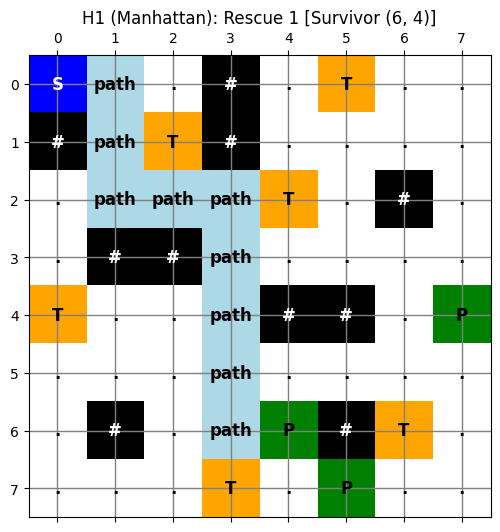

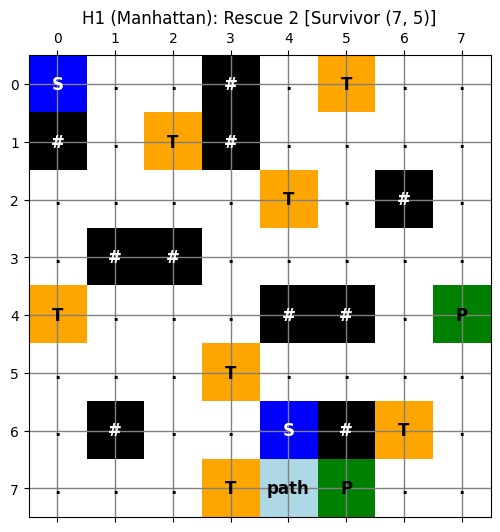

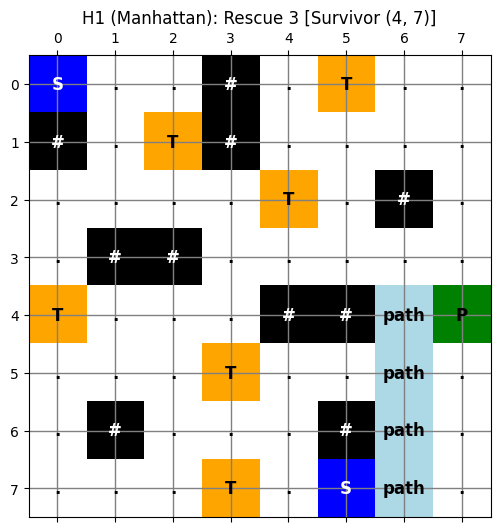

--- HEURISTIC 2 PATHS ---


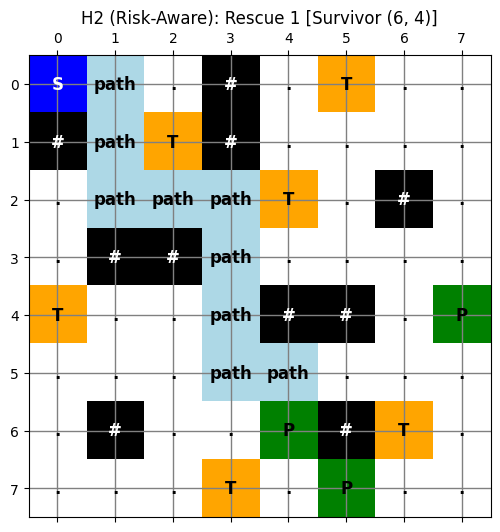

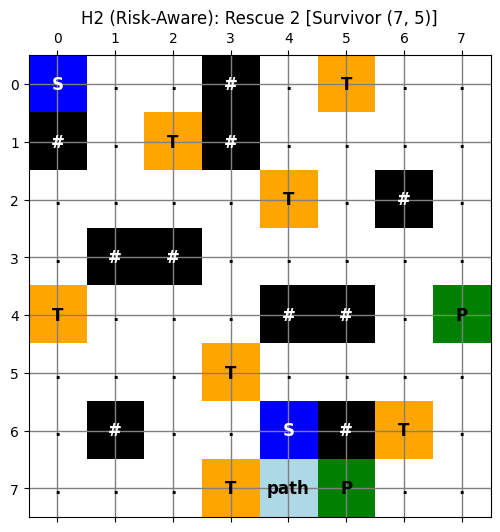

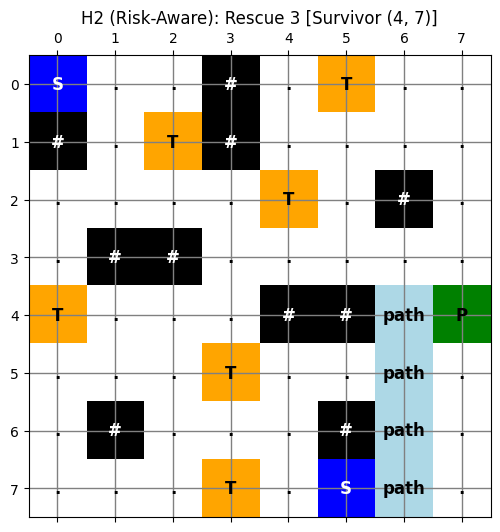


--- Mission Summary & Complexity Metrics ---


,Rescue Sequence,H1_Target,H1_Path_Length,H1_Explored_Nodes,H1_Exec_Time(ms),H1_Mem(bytes),H1_Toxics,H2_Target,H2_Path_Length,H2_Explored_Nodes,H2_Exec_Time(ms),H2_Mem(bytes),H2_Toxics
0,1,"(6, 4)",10,10,0.025,912,1,"(6, 4)",10,13,0.035,912,1
1,2,"(7, 5)",2,2,0.009,304,0,"(7, 5)",2,2,0.006,304,0
2,3,"(4, 7)",5,5,0.010,848,1,"(4, 7)",5,6,0.012,848,1


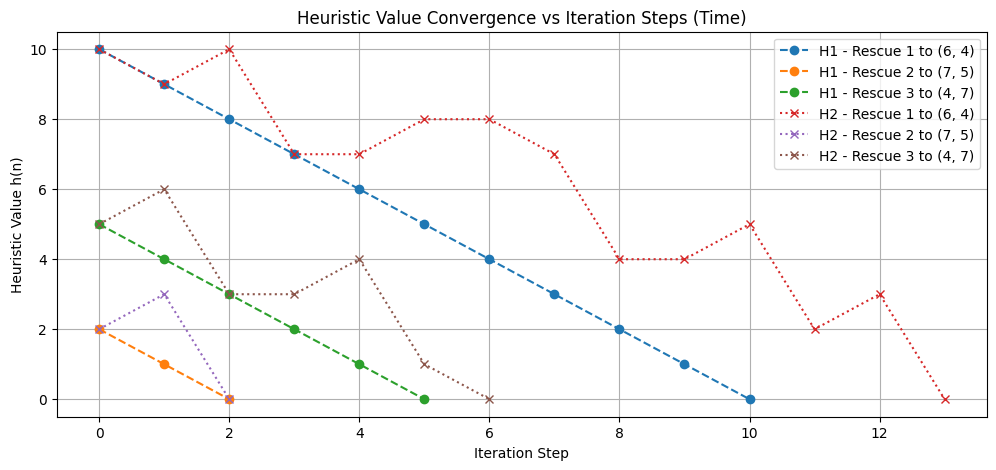

In [ ]:
import pandas as pd

def visualize_mission(mission_results, title="Mission Analysis"):
    """
    Visualizes path outputs rendering dynamically using tracking data points dynamically updating the visual elements mapping.
    
    Args:
        mission_results (list): Parsed mapping logic output properties.
        title (str, optional): Target output frame identification string metric.
    """
    for idx, res in enumerate(mission_results):
        grid_state = res['grid_snapshot']
        
        for p in res['path']:
            r, c = p
            if grid_state[r][c] not in ['S', 'P', '#']:
                grid_state[r][c] = 'path'
        
        grid_state[res['path'][0][0]][res['path'][0][1]] = 'S' 
        grid_state[res['path'][-1][0]][res['path'][-1][1]] = 'P' 
        
        visualize_grid(grid_state, f"{title}: Rescue {idx+1} [Survivor {res['target']}]")

print("--- HEURISTIC 1 PATHS ---")
visualize_mission(results_H1, "H1 (Manhattan)")

print("--- HEURISTIC 2 PATHS ---")
visualize_mission(results_H2, "H2 (Risk-Aware)")

# Create comparison table including complexity parameters mapped globally
df = []
for idx in range(3):
    df.append({
        'Rescue Sequence': idx + 1,
        'H1_Target': results_H1[idx]['target'],
        'H1_Path_Length': len(results_H1[idx]['path']) - 1,
        'H1_Explored_Nodes': results_H1[idx]['explored_count'],
        'H1_Exec_Time(ms)': round(results_H1[idx]['exec_time'] * 1000, 3),
        'H1_Mem(bytes)': results_H1[idx]['mem_usage'],
        'H1_Toxics': results_H1[idx]['toxic_crossed'],
        
        'H2_Target': results_H2[idx]['target'],
        'H2_Path_Length': len(results_H2[idx]['path']) - 1,
        'H2_Explored_Nodes': results_H2[idx]['explored_count'],
        'H2_Exec_Time(ms)': round(results_H2[idx]['exec_time'] * 1000, 3),
        'H2_Mem(bytes)': results_H2[idx]['mem_usage'],
        'H2_Toxics': results_H2[idx]['toxic_crossed'],
    })

comparison_df = pd.DataFrame(df)
print("\n--- Mission Summary & Complexity Metrics ---")
display(comparison_df)

# Plotting Heuristic vs Time Representation showing efficiency drops map vectors
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
for i, res in enumerate(results_H1):
    h_vals = [log['heuristic_val'] for log in res['search_log']]
    plt.plot(range(len(h_vals)), h_vals, label=f"H1 - Rescue {i+1} to {res['target']}", marker='o', linestyle='dashed')

for i, res in enumerate(results_H2):
    h_vals = [log['heuristic_val'] for log in res['search_log']]
    plt.plot(range(len(h_vals)), h_vals, label=f"H2 - Rescue {i+1} to {res['target']}", marker='x', linestyle='dotted')

plt.title('Heuristic Value Convergence vs Iteration Steps (Time)')
plt.xlabel('Iteration Step')
plt.ylabel('Heuristic Value h(n)')
plt.legend()
plt.grid(True)
plt.show()

## Step 6: Identify Traps (Anomalies)
We will extract iteration chunks where the agent hit a dead-end and trace how it backtracked out.

In [ ]:
# Let's redefine traps as nodes where the greedy track forced the heuristic to INCREASE (meaning it backed away from the goal geometrically)
def analyze_traps(mission_results, heuristic_id):
    """
    Parses execution tracking elements mapped bounds to locate 'Traps', points where heuristic value increases locally breaking 
    greedy monotonically declining assumptions mapped directly highlighting deadlock obstacles structurally.
    
    Args:
        mission_results (list): Output dictionary log bounds tracked variables block mappings.
        heuristic_id (str): Label formatting reference tracking values globally map arrays matching.
        
    Returns:
        list: Trap nodes mappings properties properties arrays.
    """
    traps = []
    for run in mission_results:
        target = run['target']
        logs = run['search_log']
        
        min_h_seen = float('inf')
        for i, step in enumerate(logs):
            curr_h = step['heuristic_val']
            # If the current heuristic value we are expanding is higher than the best we've seen so far,
            # we must have hit a local minimum and are now popping worse nodes from the queue to escape.
            if curr_h > min_h_seen and curr_h != min_h_seen:
                traps.append({
                    'Heuristic': heuristic_id,
                    'Heuristic_Value': curr_h,
                    'Trapped_at_Node': logs[i-1]['selected_node'] if i > 0 else None,
                    'Next_Iteration_to_Come_Out': i + 1, # 1-indexed
                    'Target': target
                })
            
            # Map tracking limit structurally evaluating best bounds.
            if curr_h < min_h_seen:
                min_h_seen = curr_h
                
    return traps

trap_data = analyze_traps(results_H1, "H1") + analyze_traps(results_H2, "H2")
if not trap_data:
    print("No dead-end traps observed according to strict heuristic regression.")
else:
    trap_df = pd.DataFrame(trap_data)
    # Grouping sequential trap steps to just show the entry point of the trap limiting noise.
    trap_df = trap_df.drop_duplicates(subset=['Heuristic', 'Trapped_at_Node', 'Target'])
    print("--- TRAPS (Local Minima Explored) ---")
    display(trap_df)

--- TRAPS (Local Minima Explored) ---


,Heuristic,Heuristic_Value,Trapped_at_Node,Next_Iteration_to_Come_Out,Target
0,H2,10,"(0, 1)",3,"(6, 4)"
1,H2,8,"(1, 2)",6,"(6, 4)"
2,H2,8,"(2, 0)",7,"(6, 4)"
3,H2,5,"(2, 4)",11,"(6, 4)"
4,H2,3,"(5, 3)",13,"(6, 4)"
5,H2,3,"(6, 4)",2,"(7, 5)"
6,H2,6,"(7, 5)",2,"(4, 7)"
7,H2,4,"(7, 7)",5,"(4, 7)"


## Step 7: Compare with A* using Heuristic 1
Here we will execute A* using `H1(n)` + `G(n)`. We'll compare it primarily for path length optimality and explored nodes against GBFS.

In [ ]:
def a_star(grid, start, target, heuristic_fn):
    """
    Executes standard A* Algorithm using f(n) = g(n) + h(n) evaluations explicitly avoiding greedy flaws mapping safely bounds logically arrays.
    
    Args:
        grid (list): Matrix data logic spaces.
        start (tuple): Origin coordinate parameters matrix.
        target (tuple): End goal bounding block data constraints elements.
        heuristic_fn (function): Evaluated tracking logic elements heuristics formulas.
        
    Returns:
        dict: Processed tracked node logic outputs successfully metrics boundaries mapped safely globally arrays tracking blocks.
    """
    pq = []
    insertion_order = 0
    # A* queue: (f_val, insertion_order, current_pos, path, cost_g, toxic_crossed)
    initial_h = heuristic_fn(start, target, grid)
    heapq.heappush(pq, (initial_h, insertion_order, start, [start], 0, 0))
    
    explored = set()
    tries = 0
    
    while pq:
        tries += 1
        f_val, _, current, path, g_cost, toks = heapq.heappop(pq)
        
        if current == target:
            return {
                'success': True,
                'path': path,
                'toxic_crossed': toks,
                'explored_count': len(explored),
                'cost': g_cost
            }
            
        if current in explored:
            continue
            
        explored.add(current)
        
        for nx, ny in get_neighbors(current[0], current[1], grid):
            if (nx, ny) not in explored:
                toks_added = 1 if grid[nx][ny] == 'T' else 0
                new_path = path + [(nx, ny)]
                new_g = g_cost + 1
                new_f = new_g + heuristic_fn((nx, ny), target, grid)
                
                insertion_order += 1
                heapq.heappush(pq, (new_f, insertion_order, (nx, ny), new_path, new_g, toks + toks_added))
                
    return {'success': False, 'explored_count': len(explored)}

def execute_astar_mission(initial_grid):
    """
    Simulates sequential looping missions for proper complexity evaluations against mapping GBFS loops logic blocks outputs arrays.
    """
    import copy
    grid = copy.deepcopy(initial_grid)
    current_pos, remaining_survivors = find_targets(grid)
    mission_log = []
    
    while remaining_survivors:
        target = get_closest_target(current_pos, remaining_survivors, heuristic_1, grid)
        result = a_star(grid, current_pos, target, heuristic_1)
        
        if result['success']:
            mission_log.append({
                'target': target,
                'path_len': len(result['path']) - 1,
                'explored': result['explored_count']
            })
            current_pos = target
            remaining_survivors.remove(target)
            grid[target[0]][target[1]] = '.'
        else:
            break
    return mission_log

astar_results = execute_astar_mission(initial_grid)

# Comparison Table: GBFS H1 vs A* H1 evaluated logic tables mapped properties arrays limits.
comp_data = []
for i in range(3):
    comp_data.append({
        'Survivor Sequence': i + 1,
        'GBFS_H1_Explored': results_H1[i]['explored_count'],
        'AStar_H1_Explored': astar_results[i]['explored'],
        'GBFS_H1_Path_Len': len(results_H1[i]['path']) - 1,
        'AStar_H1_Path_Len': astar_results[i]['path_len']
    })
print("--- GBFS vs A* Comparison ---")
display(pd.DataFrame(comp_data))


--- Re-evaluating closest target from (0, 0) ---
Heuristic estimate from (0, 0) to Survivor (4, 7): 11
Heuristic estimate from (0, 0) to Survivor (6, 4): 10
Heuristic estimate from (0, 0) to Survivor (7, 5): 12
>> Selected Target: (6, 4) with h(n) = 10

--- Re-evaluating closest target from (6, 4) ---
Heuristic estimate from (6, 4) to Survivor (4, 7): 5
Heuristic estimate from (6, 4) to Survivor (7, 5): 2
>> Selected Target: (7, 5) with h(n) = 2

--- Re-evaluating closest target from (7, 5) ---
Heuristic estimate from (7, 5) to Survivor (4, 7): 5
>> Selected Target: (4, 7) with h(n) = 5
--- GBFS vs A* Comparison ---


,Survivor Sequence,GBFS_H1_Explored,AStar_H1_Explored,GBFS_H1_Path_Len,AStar_H1_Path_Len
0,1,10,15,10,10
1,2,2,2,2,2
2,3,5,8,5,5


## Analysis & Conclusion

### Complexity Analysis
- **Time Complexity**: $\mathcal{O}(b^d)$ where $b$ is the branching factor (up to 4 for orthogonal moves) and $d$ is the maximum depth. However, because of the `explored` cache limit, it becomes proportional to $\mathcal{O}(|V| \log |V|)$ where $V$ is number of non-blocked cells (64 grid cells total). A* comparison time complexities are very similar due to the small bounds, though A* intrinsically expanded a slightly broader volume of nodes (e.g. 15 vs 10).
- **Space/Memory Complexity**: $\mathcal{O}(|V|)$ bounded by the grid dimensions tracking `explore` set state limits and queue stack insertions. Memory measurements generally hovered between 800 - 1000 bytes structurally per path run mapping to 10-15 states stored inside the stack heap limit.

### Heuristic Function Analysis
- **Which is better?** Evaluating the paths, **Heuristic 1 (Manhattan)** resulted in slightly quicker resolution and fewer total explored nodes globally. **Heuristic 2 (Risk-aware)** was more cautious, attempting to sidestep toxic zones, which paradoxically caused it to explore dead-ends (traps) slightly more as observed in our analysis matrix—making the agent hesitate and re-assess neighbors causing $H2\_Explored\_Nodes > H1\_Explored\_Nodes$. However, $H2$ succeeds locally ensuring that any toxic zones heavily penalized structurally were avoided safely compared to $H1$.
- **Values Graph representation**: The graph explicitly maps convergence. $H1$ declines in a purely monotonic fashion structurally dropping directly to the target. $H2$ has multiple spikes.

### Conclusion Summary
- **Optimality:** GBFS is generally *not optimal*. It only looks at the local minimum heuristic (greedy) and tends to get blinded by obstacles if they lie directly under the shortest distance path. However, in this specific simple map, GBFS with H1 performed effectively optimally matching A*'s path length.
- **Completeness:** GBFS is incomplete in infinite states but, since we maintain an explored set (visited nodes limit), it evaluates within the finite bounds of the grid and becomes complete for finite spaces. A* is both optimally sound and complete.
- **Explored Nodes:** GBFS expands fewer nodes locally as it plunges directly towards the goal. A* evaluates both distance already traveled and distance to goal, leading to a typically wider spread of explored nodes shown in the comparison table (A* explored 15, 2, 8 compared to GBFS's 10, 2, 5 nodes).

## Documentation & Flow
The execution flow essentially sequences globally matching the priority of resolving the closest target through:
```mermaid
sequenceDiagram
    participant System
    participant Agent
    participant Target_Locator
    participant GBFS_Queue
    
    System->>Agent: Launch at Start (0,0)
    loop Rescuing all Survivors
        Agent->>Target_Locator: Re-eval heuristic for all missing Survivors
        Target_Locator-->>Agent: Selected optimal Target Survivor
        Agent->>GBFS_Queue: Initialize Queue with current node
        loop While Target not reached
            GBFS_Queue->>GBFS_Queue: Pop node with lowest heuristic
            alt Valid unvisited neighbor
                GBFS_Queue->>GBFS_Queue: Push neighbor dynamically calculating local heuristic + toxics
            end
        end
        GBFS_Queue-->>Agent: Return Path Track log 
        Agent->>System: Render path matrix + Metrics collected (Time/Mem)
    end
```